In [3]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster

In [ ]:
local=True
if local:
    cluster=LocalCluster(memory_limit='48G')
    client = Client(cluster)
else:
    cluster=SLURMCluster(
        cores=5,#cores per slurm job
        memory="64G",#memory per slurm job
        processes=1,#dask workers per slurm job
        job_extra_directives=["-p day", 
            f"--job-name=simclust_worker",
            f"--time=0:20:00",
            f"--output=worker_%j.out"]
    )
    cluster.scale(jobs=2)
    client = Client(cluster,
            timeout=f"{10*60}s",   # Client <-> scheduler timeout 
            heartbeat_interval="20s",  # Worker heartbeat interval,
        )

2025-11-10 19:51:18,376 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 48G due to system memory limit of 30.00 GiB
2025-11-10 19:51:18,377 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 48G due to system memory limit of 30.00 GiB


2025-11-10 19:52:11,987 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:39393' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'_label_tensorzinb_regressors-f814557c53e1a678cee4164becbcd241', '_label_tensorzinb_regressors-ff42d1feef3a871a8190a5252d0090d7', '_extract_theta-f564393651f3bb33e3f6db906e825feb', '_extract_mu-977a073a3d4ffb050d5326604091a812', '_extract_zi-9378781067540688882347f4018726af', '_extract_theta-a4271517471c2ec8a6d6ccc24dd17da5', '_extract_theta-b09ba26b3839fd152bde120483d0c8a8', '_extract_mu-1ea251b3427f1550de80af7ab9c9af97', '_smart_matrix-346c9a9240be09d4a7326d7e6e8c1fb6', '_smart_matrix-8af72008602788969f8673155023148b', '_extract_zi-339923f91bf7e3bc1a706c6a4351aae3', '_extract_mu-e47262d9430e4e322c155a1cb563752f', '_extract_zi-cf57193f9bd8a9421bc41d61f1ceff92', '_extract_zi-e3b14cffb6084786fdef5cc57509fb7f', '_extract_mu-51ab9c85d74af82c5b3f474624e17d1a', '_label_tensorzinb_regressors-e39d7d1925b98

In [5]:
from pathlib import Path

In [6]:
DATA_ROOT=Path("/home/mcn26/project_pi_skr2/shared/tabula_data")
#DATA_ROOT=Path("/gpfs/gibbs/pi/reilly/tabula_data")

In [7]:
mini=scm.scMPRA_data.from_tsv(DATA_ROOT/"simulated/fake_cres_v3.tsv")

In [8]:
mini.set_negative_controls(["nobody","weak"])
mini.set_reference_cell("blood")
mini.ortho_filter()

primordial=scm.ortho()
primordial.criss_cross(client=client,
                       dat=mini)

scMPRAforge: INFO: Dropped 0 of 24 (cell_type, cre_id) combos with fewer than 3 nonzero entries.


In [9]:
primordial.extract_params(client)

In [10]:
primordial.compute_model_qc()

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns

In [12]:
def minimax(QC):
    x=[]
    for level in QC.keys():
        if QC[level]["success"]:
            x.append(QC[level]["dat"])
    x=pd.concat(x)
    print(f"min {min(x['mu'])}, max {max(x['mu'])}")

print("cre")
minimax(primordial.by_cre_qc)
print("ct")
minimax(primordial.by_cell_qc)

cre
min 1.9774204907351658, max 220.973687315239
ct
min 2.0086637727097916, max 221.141075804554


---
---
[0.9999534981068082, 0.9999801591322398, 0.9998788274940479, 0.9999974791374453, 0.9847325867492324, 0.9951134035580818, 0.9949942877992611, 0.9999894403980685, 0.9999439479848707, 0.9999946406765716, 0.9999528236343506]


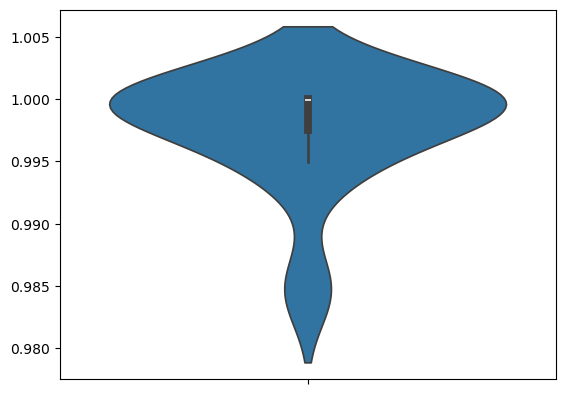

In [13]:
r=[]
for QC in [primordial.by_cre_qc,primordial.by_cell_qc]:
    print("---")
    
    for level in QC.keys():
        if QC[level]["success"]:
            if np.isnan(QC[level]["r_value"]):
                print(f"nan in {level}")
            else:
                if QC[level]["r_value"]<0.8:
                    print(f"low r {level}")
                r.append(QC[level]["r_value"])


sns.violinplot(r)

print(r)
#print(np.mean(r))
#for cell_type in QC:
#    print(f"{cell_type} : r={QC[cell_type]['r_value']}, slope={QC[cell_type]['slope']}")

In [14]:
cluster.close()
client.close()